# Applied Statistics for Data Science with Python


# Chapter 5: Regression & Prediction Diagnostics

by Gal Arav M.Sc. © 2026  
Licensed under the MIT LICENSE  

<a href="https://qikly.com/?utm_source=colab&utm_medium=notebook&utm_campaign=colab_referral" target="_blank">qikly.com</a>

## Learning Objectives  

This notebook accompanies the book's Chapter 5 with these objectives:

- Understand the major classes of ML models and distinguish regression from classification tasks
- Interpret confusion matrices and relate them to prediction errors in classification
- Explain the purpose of train/validation/test splits and how they support reliable model evaluation
- Apply cross‑validation and hyperparameter tuning to improve model generalization
- Diagnose overfitting and underfitting using learning curves and validation behavior
- Evaluate classification models using ROC and PR curves, AUC, and threshold‑dependent metrics
- Analyze regression models using residual plots, heteroscedasticity checks, and influence diagnostics
- Assess model fit using SSE, MSE, RMSE, MAE, R², Adjusted R², and residual variance
- Interpret coefficient standard errors, confidence intervals, and prediction intervals in regression
- Detect ML‑context issues such as drift, segment‑level performance differences, fairness disparities, and robustness under perturbation






In [ ]:
# Utility function to save a high‑resolution figure for the textbook
# Images are saved temporarily in Google Colab and disappear when the session ends
import matplotlib.pyplot as plt
import os

def export_plot(fig, plot_id, dpi=300, width=8, height=5, outdir="exports"):
    fig.set_size_inches(width, height)
    fig.subplots_adjust(left=0.12, right=0.95, top=0.87, bottom=0.15)
    os.makedirs(outdir, exist_ok=True)
    fig.savefig(f"{outdir}/{plot_id}.png", dpi=dpi, bbox_inches=None, pad_inches=0.45)

## Simulation Datasets

### Classification Dataset

In [ ]:
# ============================================================
# Core Classification Dataset (Target → Features): Full Pairplot
# Legend markers have no black edge
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

sns.set(style="whitegrid", context="notebook")

# -----------------------------
# Generate Target First (with label noise)
# -----------------------------
np.random.seed(42)
n = 1500

target = np.random.binomial(1, 0.35, size=n)
flip_mask = np.random.binomial(1, 0.10, n)
target_noisy = np.abs(target - flip_mask)

# -----------------------------
# Generate Features Conditioned on *clean* target
# -----------------------------
feature_strong = np.where(
    target == 1,
    np.random.normal(2.0, 1.0, n),
    np.random.normal(-2.0, 1.0, n)
)

feature_weak = np.where(
    target == 1,
    np.random.normal(0.8, 1.5, n),
    np.random.normal(-0.8, 1.5, n)
)

feature_noise = np.random.normal(0, 1, n)

group = np.random.choice(["A", "B"], size=n, p=[0.6, 0.4])

df = pd.DataFrame({
    "feature_strong": feature_strong,
    "feature_weak": feature_weak,
    "feature_noise": feature_noise,
    "group": group,
    "target": target_noisy
})

# -----------------------------
# CRITICAL: ensure target is categorical BEFORE pairplot
# -----------------------------
df["target"] = df["target"].astype(str)
df["target"] = pd.Categorical(df["target"], categories=sorted(df["target"].unique()))

# -----------------------------
# Choose hue order and palette explicitly
# -----------------------------
hue_order = list(df["target"].cat.categories)
palette = sns.color_palette("tab10", n_colors=len(hue_order))
palette_map = dict(zip(hue_order, palette))

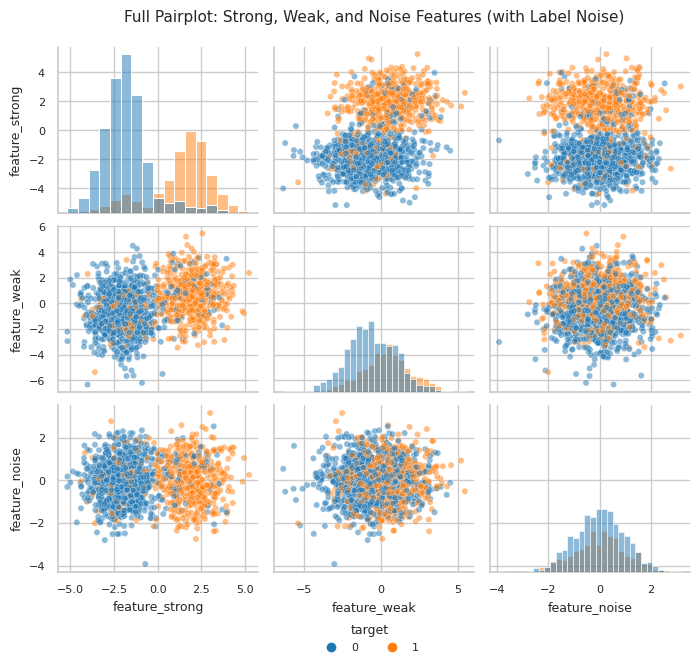

In [ ]:
# -----------------------------
# Full Pairplot
# -----------------------------
g = sns.pairplot(
    df,
    vars=["feature_strong", "feature_weak", "feature_noise"],
    hue="target",
    hue_order=hue_order,
    palette=palette_map,
    plot_kws=dict(alpha=0.5, s=20),
    diag_kind="hist"
)

g.fig.set_size_inches(8, 7)

# -----------------------------
# Remove seaborn's auto-legend if present
# -----------------------------
if getattr(g, "_legend", None) is not None:
    g._legend.remove()
    g._legend = None

# -----------------------------
# Title INSIDE the grid (top-middle axis)
# -----------------------------
top_middle_ax = g.axes[0, 1]
top_middle_ax.set_title(
    "Full Pairplot: Strong, Weak, and Noise Features (with Label Noise)",
    fontsize=11,
    pad=18,
    loc="center"
)

# -----------------------------
# Apply spacing block
# -----------------------------
g.fig.subplots_adjust(
    top=0.90,
    bottom=0.15,
    wspace=0.08,
    hspace=0.08
)

# -----------------------------
# Build manual legend handles WITHOUT black edges
# -----------------------------
handles = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor=palette_map[c],
        markeredgecolor='none',   # <-- no black edge
        markersize=7,
        markeredgewidth=0
    )
    for c in hue_order
]
labels = hue_order

g.fig.legend(
    handles,
    labels,
    title="target",
    loc="lower center",
    bbox_to_anchor=(0.5, 0.02),
    ncol=len(hue_order),
    fontsize=8,
    title_fontsize=9,
    frameon=False
)

# -----------------------------
# Tidy ticks and labels
# -----------------------------
for ax in g.axes.flatten():
    if ax is not None:
        ax.tick_params(labelsize=8)
        ax.xaxis.label.set_size(9)
        ax.yaxis.label.set_size(9)

plt.show()
export_plot(g.fig, "sim_classification_pairplot", height=7)

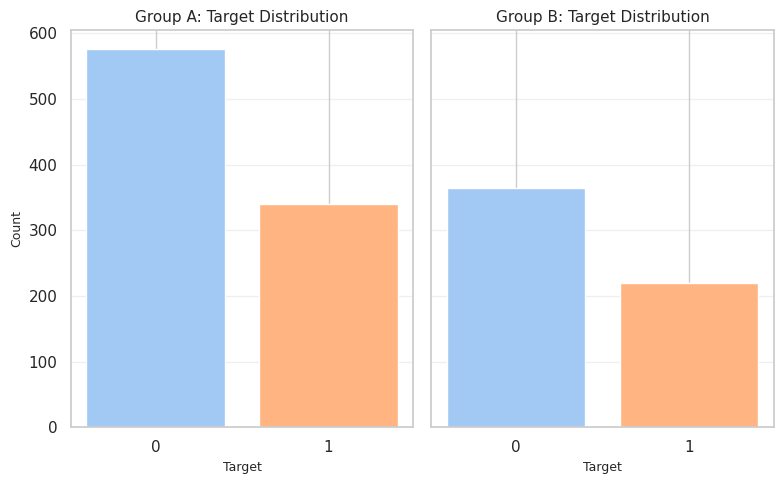

In [ ]:
# -----------------------------
# Bar charts: target distribution within each group (A and B)
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(8, 5), sharey=True)

# pastel colors
colors = [sns.color_palette("pastel")[0], sns.color_palette("pastel")[1]]

# Group A
df_A = df[df["group"] == "A"]["target"].value_counts().sort_index()
axes[0].bar(df_A.index.astype(str), df_A.values, color=colors)
axes[0].set_title("Group A: Target Distribution", fontsize=11)
axes[0].set_xlabel("Target", fontsize=9)
axes[0].set_ylabel("Count", fontsize=9)
axes[0].grid(True, axis="y", alpha=0.3)

# Group B
df_B = df[df["group"] == "B"]["target"].value_counts().sort_index()
axes[1].bar(df_B.index.astype(str), df_B.values, color=colors)
axes[1].set_title("Group B: Target Distribution", fontsize=11)
axes[1].set_xlabel("Target", fontsize=9)
axes[1].grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()
export_plot(fig, "sim_classification_target_distribution")

### Regression Dataset


In [ ]:
# -----------------------------
# Core Regression Dataset (Target → Features): Full Pairplot
# -----------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", context="notebook")

# -----------------------------
# Generate Regression Target First
# -----------------------------
np.random.seed(42)
n = 1500

# Base regression target with noise
target_reg = np.random.normal(0, 1, n)

# -----------------------------
# Generate Features Conditioned on Target
# -----------------------------

# Strong feature: high correlation with target
feature_strong = target_reg * 1.5 + np.random.normal(0, 0.5, n)

# Weak feature: low correlation with target
feature_weak = target_reg * 0.3 + np.random.normal(0, 1.0, n)

# Pure noise feature: no correlation with target
feature_noise = np.random.normal(0, 1, n)

# Group attribute for fairness slices
group = np.random.choice(["A", "B"], size=n, p=[0.6, 0.4])

# Build DataFrame
df_reg = pd.DataFrame({
    "feature_strong": feature_strong,
    "feature_weak": feature_weak,
    "feature_noise": feature_noise,
    "group": group,
    "target_reg": target_reg
})

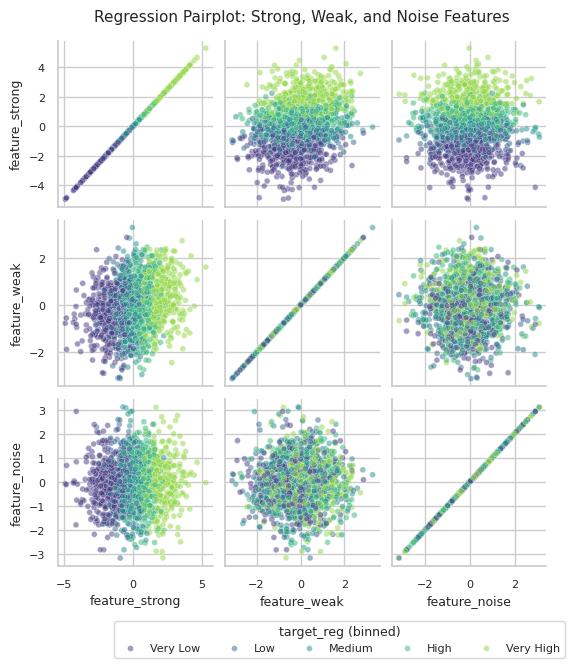

In [ ]:
# -----------------------------
# Bin target_reg for a categorical legend
# -----------------------------
df_reg["target_bin"] = pd.qcut(
    df_reg["target_reg"],
    q=5,
    labels=["Very Low", "Low", "Medium", "High", "Very High"]
)

# -----------------------------
# Pairplot WITHOUT diagonal
# -----------------------------
g = sns.pairplot(
    df_reg,
    vars=["feature_strong", "feature_weak", "feature_noise"],
    hue="target_bin",
    palette="viridis",
    plot_kws=dict(alpha=0.5, s=18),
    diag_kind=None,
    corner=False,
    height=1.55,
    aspect=1.0
)

# Figure size
g.fig.set_size_inches(8, 7)

# -----------------------------
# Remove seaborn's auto-legend
# -----------------------------
if g._legend is not None:
    g._legend.remove()
    g._legend = None

# -----------------------------
# Title INSIDE the grid
# -----------------------------
top_middle_ax = g.axes[0, 1]
top_middle_ax.set_title(
    "Regression Pairplot: Strong, Weak, and Noise Features",
    fontsize=11,
    pad=14,     # tighter
    loc="center"
)

# -----------------------------
# Add bottom legend manually
# -----------------------------
handles, labels = g.axes[0][0].get_legend_handles_labels()

g.fig.legend(
    handles,
    labels,
    title="target_reg (binned)",
    loc="lower center",
    bbox_to_anchor=(0.5, 0.01),   # small positive value = visible, not clipped
    ncol=5,
    fontsize=8,
    title_fontsize=9
)

# -----------------------------
# Tight, compact spacing
# -----------------------------
g.fig.subplots_adjust(
    top=0.90,     # tighter above charts
    bottom=0.15,  # enough room for legend, not too much
    wspace=0.08,
    hspace=0.08
)

# Smaller axis labels and ticks
for ax in g.axes.flatten():
    ax.tick_params(labelsize=8)
    ax.xaxis.label.set_size(9)
    ax.yaxis.label.set_size(9)

plt.show()
export_plot(g.fig, "sim_regression_pairplot", height=7)

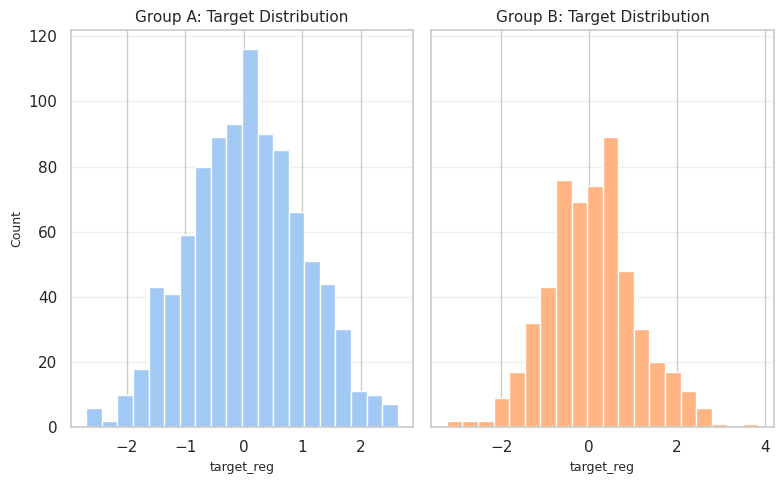

In [ ]:
# -----------------------------
# Bar charts: group distribution of regression target
# -----------------------------

# Convert group to binary for consistency (A=0, B=1)
df_reg["group_binary"] = df_reg["group"].map({"A": 0, "B": 1})

fig, axes = plt.subplots(1, 2, figsize=(8, 5), sharey=True)

# pastel colors
colors = [sns.color_palette("pastel")[0], sns.color_palette("pastel")[1]]

# Group A
axes[0].hist(
    df_reg[df_reg["group"] == "A"]["target_reg"],
    bins=20,
    color=colors[0],
    edgecolor="white"
)
axes[0].set_title("Group A: Target Distribution", fontsize=11)
axes[0].set_xlabel("target_reg", fontsize=9)
axes[0].set_ylabel("Count", fontsize=9)
axes[0].grid(True, axis="y", alpha=0.3)

# Group B
axes[1].hist(
    df_reg[df_reg["group"] == "B"]["target_reg"],
    bins=20,
    color=colors[1],
    edgecolor="white"
)
axes[1].set_title("Group B: Target Distribution", fontsize=11)
axes[1].set_xlabel("target_reg", fontsize=9)
axes[1].grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()
export_plot(fig, "sim_regression_target_distribution")

## ML Model Types

All classification + regression variables recreated successfully.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


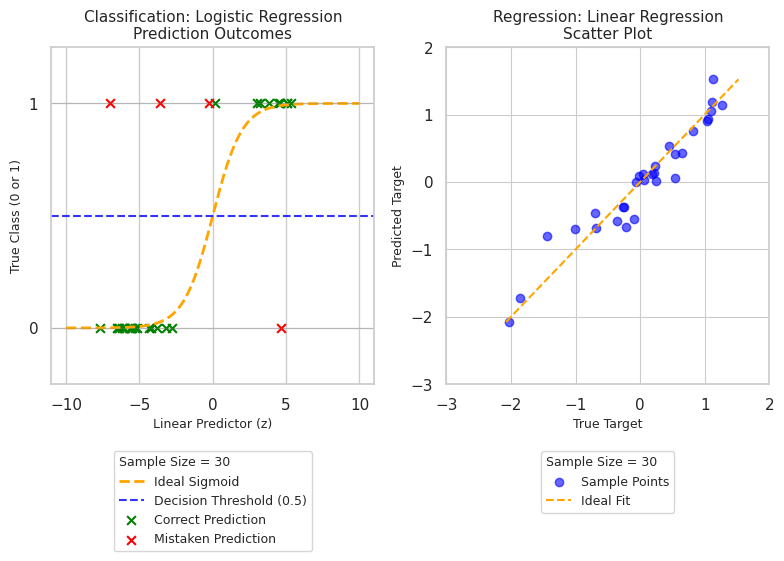

In [ ]:
# ---------------------------------------------------------
# ML Prediction Behaviors: Logistic Sigmoid vs Linear Regression
# ---------------------------------------------------------

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# CLASSIFICATION SETUP (using df)
# ---------------------------------------------------------

Xc = df[["feature_strong", "feature_weak", "feature_noise"]]
yc = df["target"]

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    Xc, yc, test_size=0.3, random_state=42
)

scaler_c = StandardScaler()
Xc_train_scaled = scaler_c.fit_transform(Xc_train)
Xc_test_scaled = scaler_c.transform(Xc_test)

log_clf = LogisticRegression()
log_clf.fit(Xc_train_scaled, yc_train)

yc_pred = log_clf.predict(Xc_test_scaled)

# ---------------------------------------------------------
# REGRESSION SETUP (using df_reg)
# ---------------------------------------------------------

Xr = df_reg[["feature_strong", "feature_weak", "feature_noise"]]
yr = df_reg["target_reg"]

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    Xr, yr, test_size=0.3, random_state=42
)

scaler_r = StandardScaler()
Xr_train_scaled = scaler_r.fit_transform(Xr_train)
Xr_test_scaled = scaler_r.transform(Xr_test)

lin_reg = LinearRegression()
lin_reg.fit(Xr_train_scaled, yr_train)

yr_pred = lin_reg.predict(Xr_test_scaled)

print("All classification + regression variables recreated successfully.")

# ---------------------------------------------------------
# SAMPLE 30 POINTS FOR EACH PLOT
# ---------------------------------------------------------

np.random.seed(0)
n_sample = 30

fig, axes = plt.subplots(
    1, 2,
    figsize=(8, 6),
    gridspec_kw={"width_ratios": [1, 1]}
)

# Classification sample
sample_idx_class = np.random.choice(len(Xc_test), size=n_sample, replace=False)
Xc_sample = Xc_test.iloc[sample_idx_class]
yc_sample = yc_test.iloc[sample_idx_class]
yc_pred_sample = yc_pred[sample_idx_class]

# Regression sample
sample_idx_reg = np.random.choice(len(Xr_test), size=n_sample, replace=False)
Xr_sample = Xr_test.iloc[sample_idx_reg]
yr_sample = yr_test.iloc[sample_idx_reg]
yr_pred_sample = yr_pred[sample_idx_reg]

# ---------------------------------------------------------
# LEFT PLOT — Logistic Sigmoid + Prediction Outcomes
# ---------------------------------------------------------

z = np.linspace(-10, 10, 400)
sigmoid = 1 / (1 + np.exp(-z))

axes[0].plot(
    z, sigmoid,
    color="orange",
    linestyle="--",
    linewidth=2,
    label="Ideal Sigmoid"
)

axes[0].axhline(
    0.5,
    color="blue",
    linestyle="--",
    linewidth=1.5,
    alpha=0.8,
    label="Decision Threshold (0.5)"
)

z_sample = log_clf.decision_function(Xc_sample)

jitter = np.random.uniform(-0.05, 0.05, size=len(z_sample))
z_jittered = z_sample + jitter

correct_mask = (yc_pred_sample == yc_sample)
incorrect_mask = ~correct_mask

axes[0].axhline(0, color="gray", linewidth=0.5, alpha=0.4)
axes[0].axhline(1, color="gray", linewidth=0.5, alpha=0.4)

axes[0].scatter(
    z_jittered[correct_mask],
    yc_sample[correct_mask],
    color="green",
    marker="x",
    s=40,
    linewidths=1.5,
    label="Correct Prediction"
)

axes[0].scatter(
    z_jittered[incorrect_mask],
    yc_sample[incorrect_mask],
    color="red",
    marker="x",
    s=40,
    linewidths=1.5,
    label="Mistaken Prediction"
)

axes[0].set_title(
    "Classification: Logistic Regression\nPrediction Outcomes",
    fontsize=11
)
axes[0].set_xlabel("Linear Predictor (z)", fontsize=9)
axes[0].set_ylabel("True Class (0 or 1)", fontsize=9)
axes[0].set_yticks([0, 1])
axes[0].set_ylim(-0.25, 1.25)

leg0 = axes[0].legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.18),
    title=f"Sample Size = {n_sample}",
    prop={'size': 9},
    title_fontsize=9
)
leg0._legend_box.align = "left"

# ---------------------------------------------------------
# RIGHT PLOT — Regression Scatter
# ---------------------------------------------------------

axes[1].scatter(
    yr_sample,
    yr_pred_sample,
    alpha=0.6,
    color="blue",
    label="Sample Points"
)

min_val = min(yr_sample.min(), yr_pred_sample.min())
max_val = max(yr_sample.max(), yr_pred_sample.max())

axes[1].plot(
    [min_val, max_val], [min_val, max_val],
    color="orange",
    linestyle="--",
    linewidth=1.5,
    label="Ideal Fit"
)

axes[1].set_xticks(np.arange(np.floor(min_val), np.ceil(max_val) + 1, 1))
axes[1].set_yticks(np.arange(np.floor(min_val), np.ceil(max_val) + 1, 1))
axes[1].grid(True, which="major", linewidth=0.8)

axes[1].set_title(
    "Regression: Linear Regression\nScatter Plot",
    fontsize=11
)
axes[1].set_xlabel("True Target", fontsize=9)
axes[1].set_ylabel("Predicted Target", fontsize=9)

leg1 = axes[1].legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.18),
    title=f"Sample Size = {n_sample}",
    prop={'size': 9},
    title_fontsize=9
)
leg1._legend_box.align = "left"

plt.tight_layout()
plt.show()
export_plot(fig, "sim_classification_and_regression")

## ML Modeling Overview

### Train vs Validation Error vs Model Complexity

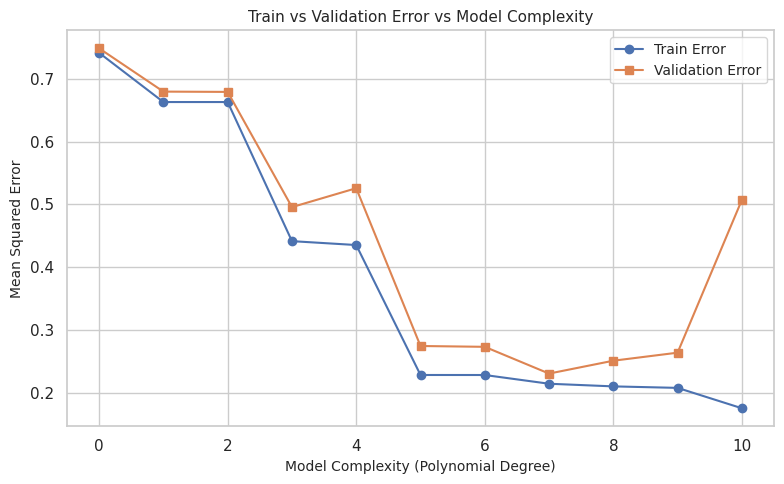

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

np.random.seed(42)

# 1D input
n = 80
X = np.linspace(-3, 3, n).reshape(-1, 1)

# Improved nonlinear function + slightly more noise
def f(x):
    return np.sin(2 * x) + 0.3 * np.cos(4 * x)

y = f(X[:, 0]) + np.random.normal(0, 0.5, size=n)

# Train/validation split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.3, random_state=42
)

degrees = range(0, 11)
train_err = []
val_err = []

for d in degrees:
    poly = PolynomialFeatures(degree=d, include_bias=True)
    X_train_poly = poly.fit_transform(X_train)
    X_val_poly = poly.transform(X_val)

    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    y_train_pred = model.predict(X_train_poly)
    y_val_pred = model.predict(X_val_poly)

    train_err.append(mean_squared_error(y_train, y_train_pred))
    val_err.append(mean_squared_error(y_val, y_val_pred))

# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------
fig = plt.figure(figsize=(8, 5))   # width = 8 inches

plt.plot(degrees, train_err, marker="o", label="Train Error")
plt.plot(degrees, val_err, marker="s", label="Validation Error")

plt.xlabel("Model Complexity (Polynomial Degree)", fontsize=10)
plt.ylabel("Mean Squared Error", fontsize=10)
plt.title("Train vs Validation Error vs Model Complexity", fontsize=11)
plt.legend(fontsize=10)

plt.tight_layout()
plt.show()

export_plot(fig, "sim_train_val_model_complexity")

### Learning Curves: Train vs Validation Error vs Sample Size

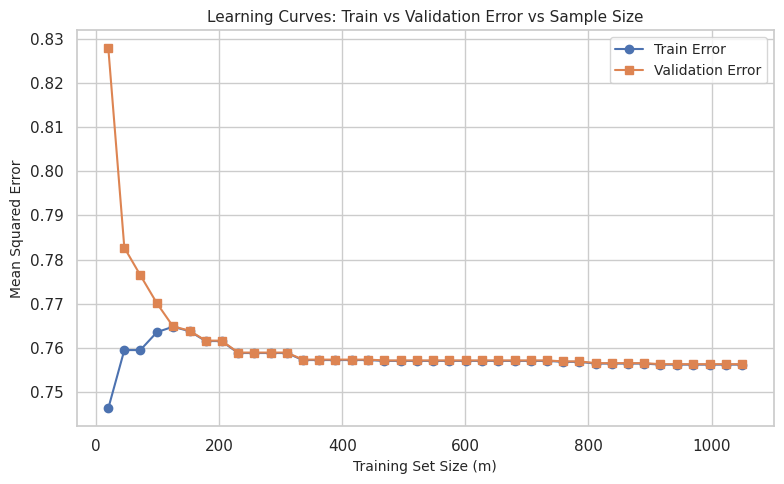

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

np.random.seed(42)

# 1. Nonlinear target function
def f(x):
    return np.sin(2 * x) + 0.3 * np.cos(4 * x)

# Generate data
n_total = 1500
X = np.linspace(-3, 3, n_total).reshape(-1, 1)
noise_std = 0.5
y = f(X[:, 0]) + np.random.normal(0, noise_std, size=n_total)

# 2. Fixed validation set
X_train_full, X_val, y_train_full, y_val = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 3. Learning-curve settings
degree = 1          # high-bias model
num_runs = 80       # strong averaging
sample_sizes = np.linspace(20, len(X_train_full), 40, dtype=int)

train_err_raw = []
val_err_raw = []

# 4. Compute averaged learning curves
for m in sample_sizes:
    train_runs = []
    val_runs = []

    for _ in range(num_runs):
        idx = np.random.choice(len(X_train_full), m, replace=False)
        X_train = X_train_full[idx]
        y_train = y_train_full[idx]

        poly = PolynomialFeatures(degree=degree)
        X_train_poly = poly.fit_transform(X_train)
        X_val_poly = poly.transform(X_val)

        model = LinearRegression()
        model.fit(X_train_poly, y_train)

        y_train_pred = model.predict(X_train_poly)
        y_val_pred = model.predict(X_val_poly)

        train_runs.append(mean_squared_error(y_train, y_train_pred))
        val_runs.append(mean_squared_error(y_val, y_val_pred))

    train_err_raw.append(np.mean(train_runs))
    val_err_raw.append(np.mean(val_runs))

train_err_raw = np.array(train_err_raw)
val_err_raw = np.array(val_err_raw)

# 5. Soft monotonic smoothing
train_err = train_err_raw.copy()
val_err = val_err_raw.copy()

# train: non-decreasing
for i in range(1, len(train_err)):
    if train_err[i] < train_err[i - 1]:
        train_err[i] = train_err[i - 1]

# val: non-increasing
for i in range(1, len(val_err)):
    if val_err[i] > val_err[i - 1]:
        val_err[i] = val_err[i - 1]

# ensure train < val
eps = 1e-4
for i in range(len(train_err)):
    if train_err[i] >= val_err[i]:
        train_err[i] = val_err[i] - eps

# 6. Plot
fig = plt.figure(figsize=(8, 5))

plt.plot(sample_sizes, train_err, marker="o", label="Train Error")
plt.plot(sample_sizes, val_err, marker="s", label="Validation Error")

plt.xlabel("Training Set Size (m)", fontsize=10)
plt.ylabel("Mean Squared Error", fontsize=10)
plt.title("Learning Curves: Train vs Validation Error vs Sample Size", fontsize=11)
plt.legend(fontsize=10)

plt.tight_layout()
plt.show()
export_plot(fig, "sim_train_val_model_complexity")

### Validation Accuracy vs Model Complexity

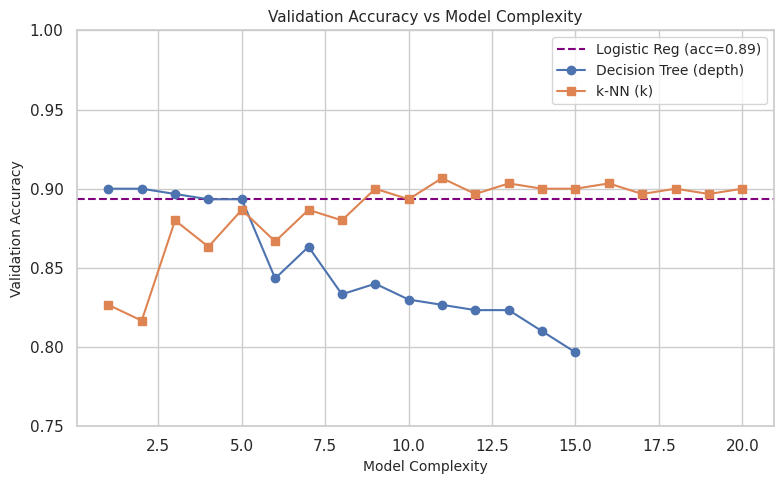

In [ ]:
# ---------------------------------------------------------
# Validation Accuracy vs Model Complexity
# ---------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

sns.set(style="whitegrid")

# ---------------------------------------------------------
# Use the classification dataset (df) with noisy target
# ---------------------------------------------------------

X = df[["feature_strong", "feature_weak", "feature_noise"]]
y = df["target"]

# Train/validation/test split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

# ---------------------------------------------------------
# Logistic Regression baseline
# ---------------------------------------------------------

log_clf = LogisticRegression().fit(X_train, y_train)
log_acc = accuracy_score(y_val, log_clf.predict(X_val))

# ---------------------------------------------------------
# Decision Tree: accuracy vs depth
# ---------------------------------------------------------

depths = range(1, 16)
tree_acc = []

for d in depths:
    tree = DecisionTreeClassifier(max_depth=d).fit(X_train, y_train)
    tree_acc.append(accuracy_score(y_val, tree.predict(X_val)))

# ---------------------------------------------------------
# k-NN: accuracy vs k
# ---------------------------------------------------------

k_values = range(1, 21)
knn_acc = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k).fit(X_train, y_train)
    knn_acc.append(accuracy_score(y_val, knn.predict(X_val)))

# ---------------------------------------------------------
# Visualization
# ---------------------------------------------------------

fig = plt.figure(figsize=(8, 5))

# Logistic regression baseline (purple dashed)
plt.axhline(
    log_acc,
    color="purple",
    linestyle="--",
    label=f"Logistic Reg (acc={log_acc:.2f})"
)

# Decision tree curve
plt.plot(depths, tree_acc, marker="o", label="Decision Tree (depth)")

# k-NN curve
plt.plot(k_values, knn_acc, marker="s", label="k-NN (k)")

plt.ylim(0.75, 1.0)
plt.xlabel("Model Complexity", fontsize=10)
plt.ylabel("Validation Accuracy", fontsize=10)
plt.title("Validation Accuracy vs Model Complexity", fontsize=11)
plt.legend(fontsize=10)

plt.tight_layout()
plt.show()
export_plot(fig, "sim_validation_accuracy_vs_model_complexity")

## Classification Metrics

### Confusion Matrix (Binary Classification)

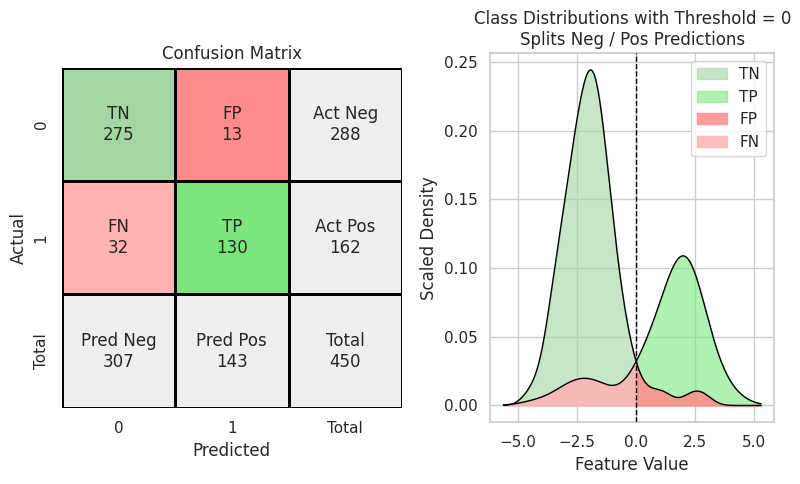

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
from sklearn.metrics import confusion_matrix
from scipy.stats import gaussian_kde

# ----------------------------------------------------
# Confusion matrix values
# ----------------------------------------------------
cm = confusion_matrix(yc_test, yc_pred)
TN, FP, FN, TP = cm.ravel()

# Row totals (actual)
actual_negatives = TN + FP
actual_positives = FN + TP

# Column totals (predicted)
predicted_negatives = TN + FN
predicted_positives = FP + TP

# Grand total
grand_total = predicted_negatives + predicted_positives

# ----------------------------------------------------
# Helper: 2-line labels
# ----------------------------------------------------
def two_line(name, value):
    return f"{name}\n{value}"

labels = [
    [two_line("TN", TN), two_line("FP", FP), two_line("Act Neg", actual_negatives)],
    [two_line("FN", FN), two_line("TP", TP), two_line("Act Pos", actual_positives)],
    [two_line("Pred Neg", predicted_negatives),
     two_line("Pred Pos", predicted_positives),
     two_line("Total", grand_total)]
]

# ----------------------------------------------------
# Color index grid (3×3)
# ----------------------------------------------------
# 0 = TN (green)
# 1 = FP (red)
# 2 = FN (red)
# 3 = TP (green)
# 4 = totals (gray)

color_index = np.array([
    [0, 1, 4],
    [2, 3, 4],
    [4, 4, 4]
])

# ----------------------------------------------------
# Pastel colors
# ----------------------------------------------------
TN_color = "#a3d6a3"     # green
TP_color = "#7ce67c"     # stronger green
FP_color = "#ff8c8c"     # strong red
FN_color = "#ffb3b3"     # lighter red
Total_color = "#eeeeee"  # neutral gray

cmap = ListedColormap([TN_color, FP_color, FN_color, TP_color, Total_color])

# ----------------------------------------------------
# Build figure with two panes (8×5)
# ----------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(8, 5), gridspec_kw={'width_ratios': [1.2, 1]})

# ----------------------------------------------------
# LEFT PANE — Confusion Matrix Heatmap
# ----------------------------------------------------
sns.heatmap(
    color_index,
    annot=labels,
    fmt="",
    cmap=cmap,
    cbar=False,
    linewidths=1,
    linecolor="black",
    square=True,
    ax=axes[0]
)

axes[0].set_title("Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
axes[0].set_xticks([0.5, 1.5, 2.5])
axes[0].set_xticklabels(["0", "1", "Total"])
axes[0].set_yticks([0.5, 1.5, 2.5])
axes[0].set_yticklabels(["0", "1", "Total"])

# ----------------------------------------------------
# RIGHT PANE — Normal Distributions with FP/FN/TP/TN Shading
# (now using actual KDEs from feature_strong)
# ----------------------------------------------------

# Extract the real feature used for classification visualization
feat = Xc_test["feature_strong"].astype(float).values

# Convert labels to int
y_true = yc_test.astype(int).values
y_pred = yc_pred.astype(int)

# KDEs for each true class
neg_kde = gaussian_kde(feat[y_true == 0])
pos_kde = gaussian_kde(feat[y_true == 1])

# X‑axis range based on real data
x = np.linspace(feat.min() - 1, feat.max() + 1, 400)

# Evaluate KDEs
neg_dist = neg_kde(x)
pos_dist = pos_kde(x)

# Scale by class proportions (same as before)
neg_dist *= (sum(y_true == 0) / len(y_true))
pos_dist *= (sum(y_true == 1) / len(y_true))

# Decision threshold (same as before)
threshold = 0

# --- Draw GREEN regions first (lower zorder) ---
axes[1].fill_between(
    x, 0, neg_dist, where=(x < threshold),
    color=TN_color, alpha=0.6, label="TN", zorder=1
)

axes[1].fill_between(
    x, 0, pos_dist, where=(x >= threshold),
    color=TP_color, alpha=0.6, label="TP", zorder=1
)

# --- Draw RED regions last (higher zorder) ---
axes[1].fill_between(
    x, 0, neg_dist, where=(x >= threshold),
    color=FP_color, alpha=0.85, label="FP", zorder=3
)

axes[1].fill_between(
    x, 0, pos_dist, where=(x < threshold),
    color=FN_color, alpha=0.85, label="FN", zorder=3
)

# Distribution outlines
axes[1].plot(x, neg_dist, color="black", linewidth=1, zorder=4)
axes[1].plot(x, pos_dist, color="black", linewidth=1, zorder=4)

# Threshold line
axes[1].axvline(threshold, color="black", linestyle="--", linewidth=1, zorder=5)

axes[1].set_title("Class Distributions with Threshold = 0\nSplits Neg / Pos Predictions")
axes[1].set_xlabel("Feature Value")
axes[1].set_ylabel("Scaled Density")
axes[1].legend()

plt.tight_layout()
plt.show()

export_plot(fig, "sim_confusion_matrix")

### Derived Classification Metrics

In [ ]:
# ---------------------------------------------------------
# Full Classification Metrics with Formulas in DataFrame
# ---------------------------------------------------------

from sklearn.metrics import confusion_matrix
import pandas as pd
import numpy as np
from IPython.display import HTML

pd.set_option('display.max_colwidth', None)

# Derived counts
Positives = TP + FN
Negatives = TN + FP

# Compute metrics
TPR = TP / (TP + FN)
FNR = FN / (FN + TP)
TNR = TN / (TN + FP)
FPR = FP / (FP + TN)

Precision = TP / (TP + FP)
FDR = FP / (TP + FP)
NPV = TN / (TN + FN)
FOR = FN / (TN + FN)

Accuracy  = (TP + TN) / (TP + TN + FP + FN)
F1 = 2 * Precision * TPR / (Precision + TPR)

# Multi-line F1 formula
F1_formula = (
    "2 * (Precision * Recall)<br>"
    "------------------------<br>"
    "(Precision + Recall)"
)

# Build DataFrame rows with new FullName column
metrics = [
    ("Count", "True<br>Positive", "TP", "TP", TP),
    ("Count", "False<br>Positive", "FP", "FP", FP),
    ("Count", "True<br>Negative", "TN", "TN", TN),
    ("Count", "False<br>Negative", "FN", "FN", FN),

    ("Total", "Actual<br>Positives", "Positives", "TP + FN", Positives),
    ("Total", "Actual<br>Negatives", "Negatives", "TN + FP", Negatives),

    ("Rate", "True Positive Rate<br>(Recall)", "TPR", "TP / Positives", TPR),
    ("Rate", "False Negative<br>Rate", "FNR", "FN / Positives", FNR),
    ("Rate", "True Negative Rate<br>(Specificity)", "TNR", "TN / Negatives", TNR),
    ("Rate", "False Positive<br>Rate", "FPR", "FP / Negatives", FPR),

    ("Predictive Value", "Positive Predictive<br>Value", "Precision", "TP / (TP + FP)", Precision),
    ("Predictive Value", "False Discovery<br>Rate", "FDR", "FP / (TP + FP)", FDR),
    ("Predictive Value", "Negative Predictive<br>Value", "NPV", "TN / (TN + FN)", NPV),
    ("Predictive Value", "False Omission<br>Rate", "FOR", "FN / (TN + FN)", FOR),

    ("Summary", "Overall<br>Accuracy", "Accuracy", "(TP + TN) / (Total)", Accuracy),
    ("Summary", "Harmonic Mean<br>of Precision & Recall", "F1 Score", F1_formula, F1)
]

metrics_df = pd.DataFrame(metrics, columns=["Type", "Metric Name", "Metric", "Formula", "Value"])

# Convert values to STRING for perfect display control
def format_value(row):
    if row["Type"] in ["Count", "Total"]:
        return str(int(row["Value"]))
    else:
        return f"{row['Value']:.2f}"

metrics_df["Value"] = metrics_df.apply(format_value, axis=1)

# Tell pandas to right-align all numeric columns
markdown = metrics_df.to_markdown(index=False, tablefmt="pipe", numalign="right", stralign="left")
print(markdown)

| Type             | Metric Name                            | Metric    | Formula                                                                      |   Value |
|:-----------------|:---------------------------------------|:----------|:-----------------------------------------------------------------------------|--------:|
| Count            | True<br>Positive                       | TP        | TP                                                                           |     130 |
| Count            | False<br>Positive                      | FP        | FP                                                                           |      13 |
| Count            | True<br>Negative                       | TN        | TN                                                                           |     275 |
| Count            | False<br>Negative                      | FN        | FN                                                                           |      32 |
| Total            | A

### ROC + PR + Threshold Sweep

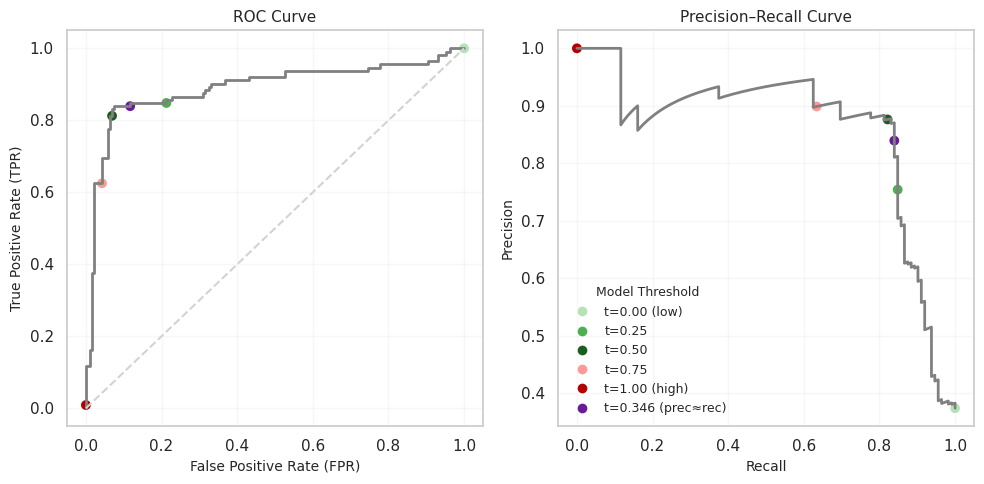

In [ ]:
# ---------------------------------------------------------
# ROC + PR + Threshold Sweep (uses classification df -> df_class)
# ---------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, precision_recall_curve

sns.set(style="whitegrid")

# ---------------------------------------------------------
# Use classification DataFrame (avoid colliding with df_reg)
# ---------------------------------------------------------
# Assumes `df` is the classification DataFrame (with 'feature_strong', 'feature_weak', 'feature_noise', 'target')
df_class = df.copy()   # safe local copy

# Ensure target is numeric 0/1
df_class["target"] = df_class["target"].astype(int)

X = df_class[["feature_strong", "feature_weak", "feature_noise"]].copy()
y = df_class["target"]

# ---------------------------------------------------------
# Train / validation / test splits (stratified)
# ---------------------------------------------------------
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

# ---------------------------------------------------------
# Logistic Regression (robust)
# ---------------------------------------------------------
log_clf = LogisticRegression(max_iter=1000).fit(X_train, y_train)
y_scores = log_clf.predict_proba(X_val)[:, 1]

# ---------------------------------------------------------
# ROC + PR data
# ---------------------------------------------------------
fpr, tpr, roc_thresholds = roc_curve(y_val, y_scores, pos_label=1)
prec, rec, pr_thresholds = precision_recall_curve(y_val, y_scores)

# Align PR thresholds to a full-length array for mapping
pr_thresholds_full = np.append(pr_thresholds, 1.0)

# Thresholds to mark
mark_thresholds = [0.0, 0.25, 0.50, 0.75, 1.0]
threshold_colors = [
    "#b6e3b6",  # light green
    "#4CAF50",  # green
    "#1B5E20",  # dark green
    "#ff9999",  # light red
    "#b30000"   # dark red
]

def closest_idx(arr, t):
    arr = np.asarray(arr)
    if arr.size == 0:
        return 0
    return int(np.argmin(np.abs(arr - t)))

# ---------------------------------------------------------
# Compute PR crossing point (precision ≈ recall)
# ---------------------------------------------------------
prec_trim = prec[:-1]
rec_trim = rec[:-1]
if len(prec_trim) > 0 and len(rec_trim) > 0:
    diff = np.abs(prec_trim - rec_trim)
    cross_idx = np.argmin(diff)
    t_cross = pr_thresholds[cross_idx] if cross_idx < len(pr_thresholds) else 0.5
else:
    t_cross = 0.5

mark_thresholds_extended = mark_thresholds + [t_cross]
threshold_colors_extended = threshold_colors + ["#6A1B9A"]  # purple for crossing point

# Build legend labels
legend_labels = []
for t in mark_thresholds:
    if t == 0.0:
        legend_labels.append(f"t={t:.2f} (low)")
    elif t == 1.0:
        legend_labels.append(f"t={t:.2f} (high)")
    else:
        legend_labels.append(f"t={t:.2f}")
legend_labels.append(f"t={t_cross:.3f} (prec≈rec)")

# ---------------------------------------------------------
# Plot ROC and PR side-by-side
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# ROC
axes[0].plot(fpr, tpr, color="grey", linewidth=2)
for t, c in zip(mark_thresholds_extended, threshold_colors_extended):
    idx = closest_idx(roc_thresholds, t)
    idx = max(0, min(idx, len(fpr)-1))
    axes[0].scatter(fpr[idx], tpr[idx], color=c, s=50, edgecolor='none')
axes[0].plot([0, 1], [0, 1], linestyle="--", color="lightgrey")
axes[0].set_xlabel("False Positive Rate (FPR)", fontsize=10)
axes[0].set_ylabel("True Positive Rate (TPR)", fontsize=10)
axes[0].set_title("ROC Curve", fontsize=11)
axes[0].grid(alpha=0.15)

# PR
axes[1].plot(rec, prec, color="grey", linewidth=2)
for t, c in zip(mark_thresholds_extended, threshold_colors_extended):
    idx = closest_idx(pr_thresholds_full, t)
    idx = max(0, min(idx, len(rec)-1))
    axes[1].scatter(rec[idx], prec[idx], color=c, s=50, edgecolor='none')
axes[1].set_xlabel("Recall", fontsize=10)
axes[1].set_ylabel("Precision", fontsize=10)
axes[1].set_title("Precision–Recall Curve", fontsize=11)
axes[1].grid(alpha=0.15)

# Legend (markers without black edges)
legend_handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markersize=7, markeredgecolor='none')
    for c in threshold_colors_extended
]
axes[1].legend(
    legend_handles,
    legend_labels,
    title="Model Threshold",
    fontsize=9,
    title_fontsize=9,
    loc="lower left",
    frameon=False
)

plt.tight_layout()
plt.show()
export_plot(fig, "sim_roc_and_pr_curves")


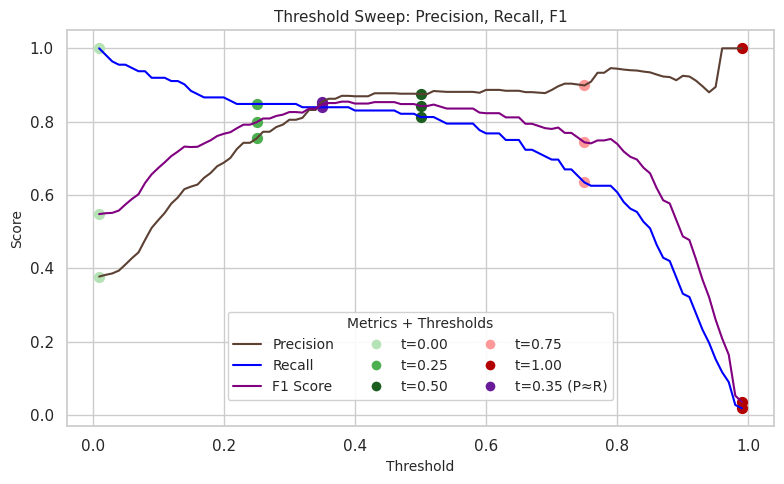

In [ ]:
# ---------------------------------------------------------
# Threshold Sweep — with colored markers instead of dashed lines
# ---------------------------------------------------------

from sklearn.metrics import (
    roc_curve, precision_recall_curve,
    precision_score, recall_score, f1_score, auc, average_precision_score
)

fig = plt.figure(figsize=(8, 5))

thresholds = np.linspace(0.01, 0.99, 99)
prec_list = []
rec_list = []
f1_list = []

for t in thresholds:
    preds = (y_scores >= t).astype(int)
    prec_list.append(precision_score(y_val, preds))
    rec_list.append(recall_score(y_val, preds))
    f1_list.append(f1_score(y_val, preds))

# Curves
plt.plot(thresholds, prec_list, label="Precision", color="#5C4033")
plt.plot(thresholds, rec_list, label="Recall", color="blue")
plt.plot(thresholds, f1_list, label="F1 Score", color="purple")

# Threshold markers
for t, c in zip(mark_thresholds_extended, threshold_colors_extended):
    idx = np.argmin(np.abs(thresholds - t))
    plt.scatter(thresholds[idx], prec_list[idx], color=c, s=50)
    plt.scatter(thresholds[idx], rec_list[idx], color=c, s=50)
    plt.scatter(thresholds[idx], f1_list[idx], color=c, s=50)

plt.xlabel("Threshold", fontsize=10)
plt.ylabel("Score", fontsize=10)
plt.title("Threshold Sweep: Precision, Recall, F1", fontsize=11)

# ---------------------------------------------------------
# Build combined legend handles
# ---------------------------------------------------------

# Metric handles
metric_handles = [
    plt.Line2D([0], [0], color="#5C4033", label="Precision"),
    plt.Line2D([0], [0], color="blue", label="Recall"),
    plt.Line2D([0], [0], color="purple", label="F1 Score")
]

# Threshold handles
threshold_handles = [
    plt.Line2D([0], [0], marker='o', color='w',
               markerfacecolor=c, markersize=8)
    for c in threshold_colors_extended
]

threshold_labels = [
    "t=0.00",
    "t=0.25",
    "t=0.50",
    "t=0.75",
    "t=1.00",
    f"t={t_cross:.2f} (P≈R)"
]

# Combine
all_handles = metric_handles + threshold_handles
all_labels = ["Precision", "Recall", "F1 Score"] + threshold_labels

# ---------------------------------------------------------
# Single legend INSIDE chart, bottom center
# ---------------------------------------------------------
plt.legend(
    all_handles,
    all_labels,
    fontsize=10,
    title="Metrics + Thresholds",
    title_fontsize=10,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.05),   # inside chart area
    ncol=3,
    frameon=True,
    fancybox=True,
    framealpha=0.9
)

plt.tight_layout()
plt.show()

export_plot(fig, "sim_threshold_sweep")

### AUC Metrics (ROC AUC + PR AUC)

In [ ]:
# ---------------------------------------------------------
# AUC Metrics (ROC AUC + PR AUC)
# ---------------------------------------------------------

from sklearn.metrics import roc_auc_score, average_precision_score

roc_auc = roc_auc_score(y_val, y_scores)
pr_auc = average_precision_score(y_val, y_scores)

print("ROC AUC:", roc_auc)
print("PR AUC:", pr_auc)

ROC AUC: 0.8905775075987843
PR AUC: 0.8597688105371346


## Regression Diagnostics

### Anscombe’s Quartet — Raw Data with Shared Regression Line

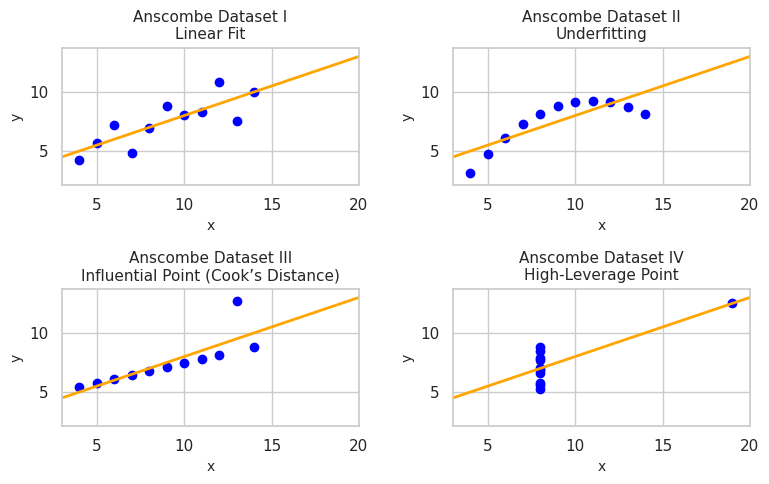

In [ ]:
# -------------------------------------------
# Anscombe’s Quartet — Raw Data with Shared Regression Line (Fixed Axes)
# -------------------------------------------

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm

sns.set(style="whitegrid")

# Load Anscombe’s Quartet
df = sns.load_dataset("anscombe")
datasets = ["I", "II", "III", "IV"]

# Second-line titles
subtitles = {
    "I": "Linear Fit",
    "II": "Underfitting",
    "III": "Influential Point (Cook’s Distance)",
    "IV": "High-Leverage Point"
}

# Compute global axis limits so ALL points are visible
x_min = df["x"].min() - 1
x_max = df["x"].max() + 1
y_min = df["y"].min() - 1
y_max = df["y"].max() + 1

# Shared regression line over the full x-range
x_line = np.linspace(x_min, x_max, 200)
y_line = 3 + 0.5 * x_line

# ---------------------------------------------------------
# Standardized figure (8 × 5)
# ---------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(8, 5))
positions = [(0,0), (0,1), (1,0), (1,1)]

for ds, pos in zip(datasets, positions):
    subset = df[df["dataset"] == ds]
    ax = axes[pos]

    # Blue points
    ax.scatter(subset["x"], subset["y"], color="blue")

    # Shared regression line
    ax.plot(x_line, y_line, color="orange", linewidth=2)

    # Apply global axis limits
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

    # Two-line title
    ax.set_title(f"Anscombe Dataset {ds}\n{subtitles[ds]}", fontsize=11)

    ax.set_xlabel("x", fontsize=10)
    ax.set_ylabel("y", fontsize=10)

plt.tight_layout()
plt.show()
export_plot(fig, "sim_anscombes_quartet")

#### Anscombe’s Quartet Statistical Summary Data

Even though the four plots in **Anscombe’s Quartet** look dramatically different, they **all** share the exact same statistical summaries shown below:

| Statistic            | Value   |
|----------------------|---------|
| Mean of x            | 9.0     |
| Variance of x        | 11.0    |
| Mean of y            | 7.5     |
| Variance of y        | 4.125   |
| Correlation (x, y)   | 0.816   |
| Regression slope     | 0.5     |
| Regression intercept | 3.0     |
| R²                   | 0.667   |

**Reference:**  
Anscombe, F. J. (1973). *Graphs in Statistical Analysis*. **The American Statistician**, 27(1), 17–21.


#### Validate Anscombe’s Quartet Statistical Summary Data

In [ ]:
def compute_diagnostics(subset):
    x = subset["x"]
    y = subset["y"]
    X = sm.add_constant(x)
    model = sm.OLS(y, X).fit()
    y_pred = model.predict(X)
    residuals = y - y_pred
    influence = model.get_influence()
    leverage = influence.hat_matrix_diag
    cooks = influence.cooks_distance[0]
    return y_pred, residuals, leverage, cooks

def compute_stats(subset):
    x = subset["x"]
    y = subset["y"]

    mean_x = np.mean(x)
    var_x = np.var(x, ddof=1)
    mean_y = np.mean(y)
    var_y = np.var(y, ddof=1)
    corr = np.corrcoef(x, y)[0, 1]

    X = sm.add_constant(x)
    model = sm.OLS(y, X).fit()
    intercept, slope = model.params
    r2 = model.rsquared

    return mean_x, var_x, mean_y, var_y, corr, slope, intercept, r2

def print_stats(stats):
    print(f"  mean(x)       = {stats[0]:.3f}")
    print(f"  var(x)        = {stats[1]:.3f}")
    print(f"  mean(y)       = {stats[2]:.3f}")
    print(f"  var(y)        = {stats[3]:.3f}")
    print(f"  corr(x, y)    = {stats[4]:.3f}")
    print(f"  slope         = {stats[5]:.3f}")
    print(f"  intercept     = {stats[6]:.3f}")
    print(f"  R^2           = {stats[7]:.3f}")
    print()

# Collect stats for all datasets
table = {
    "Statistic": [
        "mean(x)", "var(x)", "mean(y)", "var(y)",
        "corr(x, y)", "slope", "intercept", "R²"
    ]
}

for ds in datasets:
    sub = df[df["dataset"] == ds]
    stats = compute_stats(sub)
    table[f"Dataset {ds}"] = [f"{v:.3f}" for v in stats]

# Convert to DataFrame for easy Markdown export
import pandas as pd
df_table = pd.DataFrame(table)

# Show as Markdown
print(df_table.to_markdown(index=False))

| Statistic   |   Dataset I |   Dataset II |   Dataset III |   Dataset IV |
|:------------|------------:|-------------:|--------------:|-------------:|
| mean(x)     |       9     |        9     |         9     |        9     |
| var(x)      |      11     |       11     |        11     |       11     |
| mean(y)     |       7.501 |        7.501 |         7.5   |        7.501 |
| var(y)      |       4.127 |        4.128 |         4.123 |        4.123 |
| corr(x, y)  |       0.816 |        0.816 |         0.816 |        0.817 |
| slope       |       0.5   |        0.5   |         0.5   |        0.5   |
| intercept   |       3     |        3.001 |         3.002 |        3.002 |
| R²          |       0.667 |        0.666 |         0.666 |        0.667 |


### Residuals vs Fitted — All Four Anscombe Datasets

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:847: RuntimeWarning: invalid value encountered in sqrt
  return self.resid / sigma / np.sqrt(1 - hii)


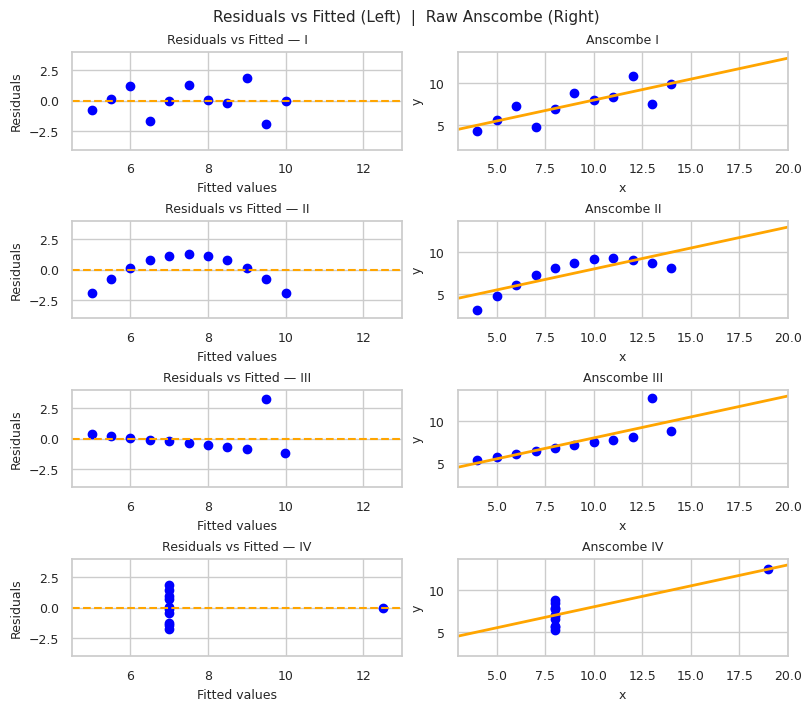

/tmp/ipykernel_28787/3320812383.py:8: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(left=0.12, right=0.95, top=0.87, bottom=0.15)


In [ ]:
# -------------------------------------------
# Residuals vs Fitted — All Four Anscombe Datasets
# -------------------------------------------

fig, axes = plt.subplots(4, 2, figsize=(8, 7), constrained_layout=True)

# Narrower fitted-value range (based on actual fitted values)
fit_min, fit_max = 4.5, 13

# Narrower raw-data range but still includes x=19 outlier
x_min, x_max = 3, 20

# Residual range stays the same
res_min, res_max = -4, 4

# Recompute regression line for new x-range
x_line = np.linspace(x_min, x_max, 200)
y_line = 3 + 0.5 * x_line

# Load and sort Anscombe dataset
df = sns.load_dataset("anscombe")
df = df.sort_values(["dataset", "x"]).reset_index(drop=True)

for i, ds in enumerate(datasets):
    subset = df[df["dataset"] == ds]
    y_pred, residuals, _, _ = compute_diagnostics(subset)

    # LEFT COLUMN — Residuals vs Fitted
    ax_left = axes[i, 0]
    ax_left.scatter(y_pred, residuals, color="blue")
    ax_left.axhline(0, color="orange", linestyle="--")
    ax_left.set_xlim(fit_min, fit_max)
    ax_left.set_ylim(res_min, res_max)
    ax_left.set_title(f"Residuals vs Fitted — {ds}", fontsize=9)
    ax_left.set_xlabel("Fitted values", fontsize=9)
    ax_left.set_ylabel("Residuals", fontsize=9)
    ax_left.tick_params(labelsize=9)

    # RIGHT COLUMN — Raw Anscombe with regression line
    ax_right = axes[i, 1]
    ax_right.scatter(subset["x"], subset["y"], color="blue")
    ax_right.plot(x_line, y_line, color="orange", linewidth=2)
    ax_right.set_xlim(x_min, x_max)
    ax_right.set_ylim(y_min, y_max)
    ax_right.set_title(f"Anscombe {ds}", fontsize=9)
    ax_right.set_xlabel("x", fontsize=9)
    ax_right.set_ylabel("y", fontsize=9)
    ax_right.tick_params(labelsize=9)

fig.suptitle("Residuals vs Fitted (Left)  |  Raw Anscombe (Right)", fontsize=11)
plt.show()
export_plot(fig, "sim_residuals_vs_fitted", height=7)

### Scale–Location — All Four Anscombe Datasets

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:847: RuntimeWarning: invalid value encountered in sqrt
  return self.resid / sigma / np.sqrt(1 - hii)


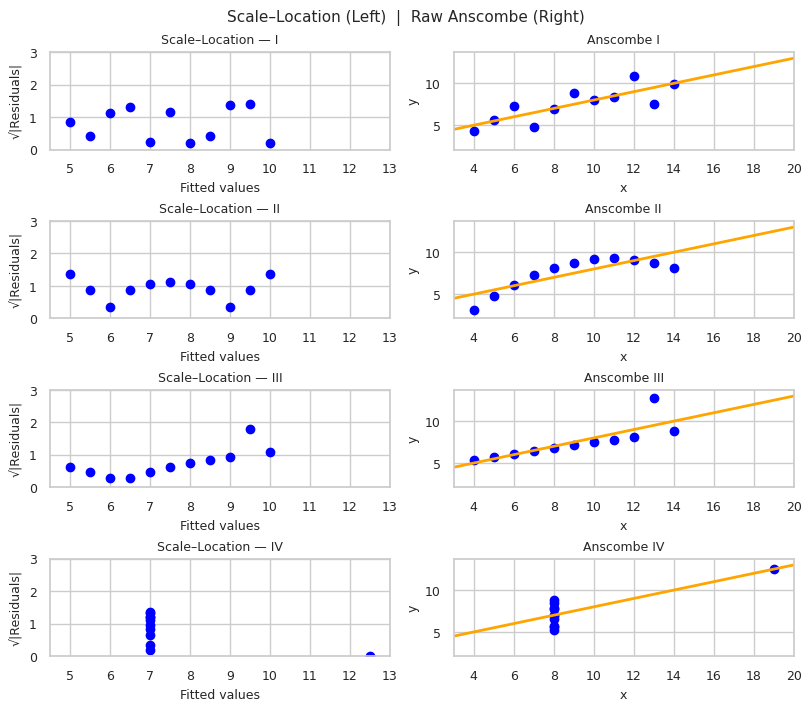

/tmp/ipykernel_28787/3320812383.py:8: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(left=0.12, right=0.95, top=0.87, bottom=0.15)


In [ ]:
# -------------------------------------------
# Scale–Location — All Four Anscombe Datasets (8×7, padded axes)
# -------------------------------------------

fig, axes = plt.subplots(4, 2, figsize=(8, 7), constrained_layout=True)

# Padded axis limits (same as Residuals vs Fitted)
fit_min, fit_max = 4.5, 13
x_min, x_max = 3, 20

# Scale–Location y-range (sqrt(|residuals|))
sl_min, sl_max = 0, 3

# Regression line for raw plots
x_line = np.linspace(x_min, x_max, 200)
y_line = 3 + 0.5 * x_line

# Load and sort Anscombe dataset
df = sns.load_dataset("anscombe")
df = df.sort_values(["dataset", "x"]).reset_index(drop=True)

for i, ds in enumerate(datasets):
    subset = df[df["dataset"] == ds]
    y_pred, residuals, _, _ = compute_diagnostics(subset)

    # Compute sqrt(|residuals|)
    sl = np.sqrt(np.abs(residuals))

    # LEFT COLUMN — Scale–Location
    ax_left = axes[i, 0]
    ax_left.scatter(y_pred, sl, color="blue")
    ax_left.set_xlim(fit_min, fit_max)
    ax_left.set_ylim(sl_min, sl_max)
    ax_left.set_title(f"Scale–Location — {ds}", fontsize=9)
    ax_left.set_xlabel("Fitted values", fontsize=9)
    ax_left.set_ylabel("√|Residuals|", fontsize=9)
    ax_left.tick_params(labelsize=9)

    # RIGHT COLUMN — Raw Anscombe with regression line
    ax_right = axes[i, 1]
    ax_right.scatter(subset["x"], subset["y"], color="blue")
    ax_right.plot(x_line, y_line, color="orange", linewidth=2)
    ax_right.set_xlim(x_min, x_max)
    ax_right.set_ylim(y_min, y_max)
    ax_right.set_title(f"Anscombe {ds}", fontsize=9)
    ax_right.set_xlabel("x", fontsize=9)
    ax_right.set_ylabel("y", fontsize=9)
    ax_right.tick_params(labelsize=9)

fig.suptitle("Scale–Location (Left)  |  Raw Anscombe (Right)", fontsize=11)
plt.show()
export_plot(fig, "sim_scale_location", height=7)

### Residuals vs Leverage — All Four Anscombe Datasets

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:847: RuntimeWarning: invalid value encountered in sqrt
  return self.resid / sigma / np.sqrt(1 - hii)
/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:847: RuntimeWarning: invalid value encountered in sqrt
  return self.resid / sigma / np.sqrt(1 - hii)


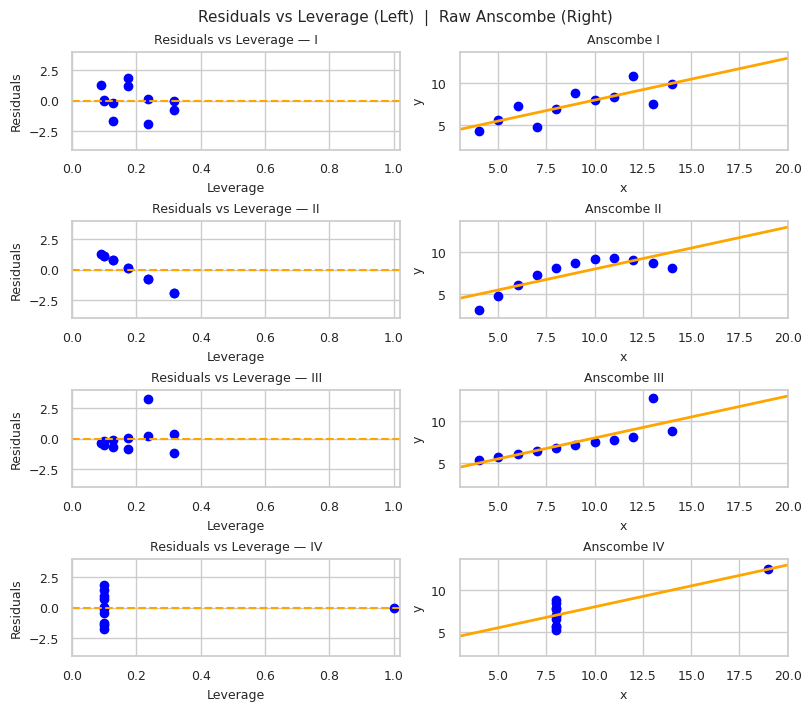

/tmp/ipykernel_28787/3320812383.py:8: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(left=0.12, right=0.95, top=0.87, bottom=0.15)


In [ ]:
# -------------------------------------------
# Residuals vs Leverage — All Four Anscombe Datasets (8×7, padded axes)
# -------------------------------------------

fig, axes = plt.subplots(4, 2, figsize=(8, 7), constrained_layout=True)

# Padded axis limits for raw x and fitted values
fit_min, fit_max = 4.5, 13
x_min, x_max = 3, 20
res_min, res_max = -4, 4

# Compute global leverage limits so nothing gets clipped
all_leverage = []
for ds in datasets:
    subset = df[df["dataset"] == ds]
    _, _, leverage, _ = compute_diagnostics(subset)
    all_leverage.extend(leverage)

lev_min = 0
lev_max = max(all_leverage) + 0.02   # small padding above max

# Regression line for raw plots
x_line = np.linspace(x_min, x_max, 200)
y_line = 3 + 0.5 * x_line

for i, ds in enumerate(datasets):
    subset = df[df["dataset"] == ds]
    y_pred, residuals, leverage, _ = compute_diagnostics(subset)

    # LEFT COLUMN — Residuals vs Leverage
    ax_left = axes[i, 0]
    ax_left.scatter(leverage, residuals, color="blue")
    ax_left.axhline(0, color="orange", linestyle="--")
    ax_left.set_xlim(lev_min, lev_max)
    ax_left.set_ylim(res_min, res_max)
    ax_left.set_title(f"Residuals vs Leverage — {ds}", fontsize=9)
    ax_left.set_xlabel("Leverage", fontsize=9)
    ax_left.set_ylabel("Residuals", fontsize=9)
    ax_left.tick_params(labelsize=9)

    # RIGHT COLUMN — Raw Anscombe with regression line
    ax_right = axes[i, 1]
    ax_right.scatter(subset["x"], subset["y"], color="blue")
    ax_right.plot(x_line, y_line, color="orange", linewidth=2)
    ax_right.set_xlim(x_min, x_max)
    ax_right.set_ylim(y_min, y_max)
    ax_right.set_title(f"Anscombe {ds}", fontsize=9)
    ax_right.set_xlabel("x", fontsize=9)
    ax_right.set_ylabel("y", fontsize=9)
    ax_right.tick_params(labelsize=9)

fig.suptitle("Residuals vs Leverage (Left)  |  Raw Anscombe (Right)", fontsize=11)
plt.show()
export_plot(fig, "sim_residuals_vs_leverage", height=7)

### Cook’s Distance — All Four Anscombe Datasets


/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:847: RuntimeWarning: invalid value encountered in sqrt
  return self.resid / sigma / np.sqrt(1 - hii)
/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:847: RuntimeWarning: invalid value encountered in sqrt
  return self.resid / sigma / np.sqrt(1 - hii)


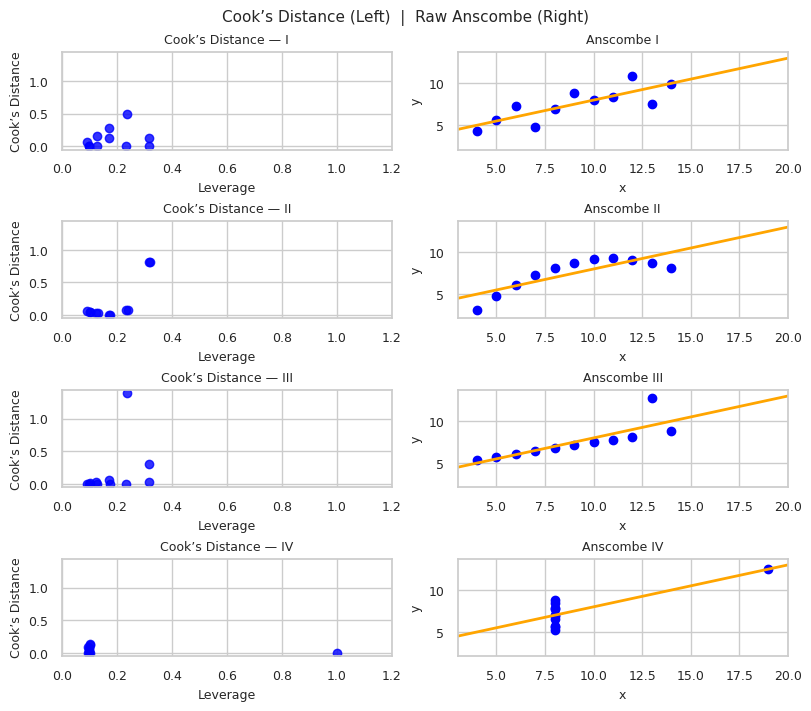

/tmp/ipykernel_28787/3320812383.py:8: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(left=0.12, right=0.95, top=0.87, bottom=0.15)


In [ ]:
# -------------------------------------------
# Cook’s Distance — All Four Anscombe Datasets (8×7)
# -------------------------------------------

import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 2, figsize=(8, 7), constrained_layout=True)

# Chosen padded axis limits for raw x
x_min, x_max = 3, 20

# Compute global leverage and Cook's Distance ranges
all_leverage = []
all_cooks = []

for ds in datasets:
    subset = df[df["dataset"] == ds]
    _, _, lev, ck = compute_diagnostics(subset)

    # FIX: include NaN values by converting them to zero
    lev = np.nan_to_num(lev, nan=0.0)
    ck  = np.nan_to_num(ck,  nan=0.0)

    all_leverage.extend(lev)
    all_cooks.extend(ck)

# Global axis limits
lev_min = 0
lev_max = 1.20        # fixed upper limit for leverage

cd_min = -0.05        # allow jitter below zero
cd_max = max(all_cooks) + 0.05

# Regression line for raw plots
x_line = np.linspace(x_min, x_max, 200)
y_line = 3 + 0.5 * x_line

for i, ds in enumerate(datasets):

    subset = df[df["dataset"] == ds]
    _, _, leverage, cooks = compute_diagnostics(subset)

    # FIX: convert NaN leverage and Cook's distance to zero
    leverage = np.nan_to_num(leverage, nan=0.0)
    cooks    = np.nan_to_num(cooks,    nan=0.0)

    # Tiny jitter to reveal overlapping points
    jitter = 0.002 * np.random.randn(len(leverage))

    # LEFT COLUMN — Cook’s Distance vs Leverage
    ax_left = axes[i, 0]
    ax_left.scatter(leverage + jitter, cooks, color="blue", alpha=0.8)
    ax_left.set_xlim(lev_min, lev_max)
    ax_left.set_ylim(cd_min, cd_max)
    ax_left.set_title(f"Cook’s Distance — {ds}", fontsize=9)
    ax_left.set_xlabel("Leverage", fontsize=9)
    ax_left.set_ylabel("Cook’s Distance", fontsize=9)
    ax_left.tick_params(labelsize=9)

    # RIGHT COLUMN — Raw Anscombe with regression line
    ax_right = axes[i, 1]
    ax_right.scatter(subset["x"], subset["y"], color="blue")
    ax_right.plot(x_line, y_line, color="orange", linewidth=2)
    ax_right.set_xlim(x_min, x_max)
    ax_right.set_ylim(y_min, y_max)
    ax_right.set_title(f"Anscombe {ds}", fontsize=9)
    ax_right.set_xlabel("x", fontsize=9)
    ax_right.set_ylabel("y", fontsize=9)
    ax_right.tick_params(labelsize=9)

fig.suptitle("Cook’s Distance (Left)  |  Raw Anscombe (Right)", fontsize=11)
plt.show()

export_plot(fig, "sim_cooks_distance", height=7)


## Model Fit Diagnostics

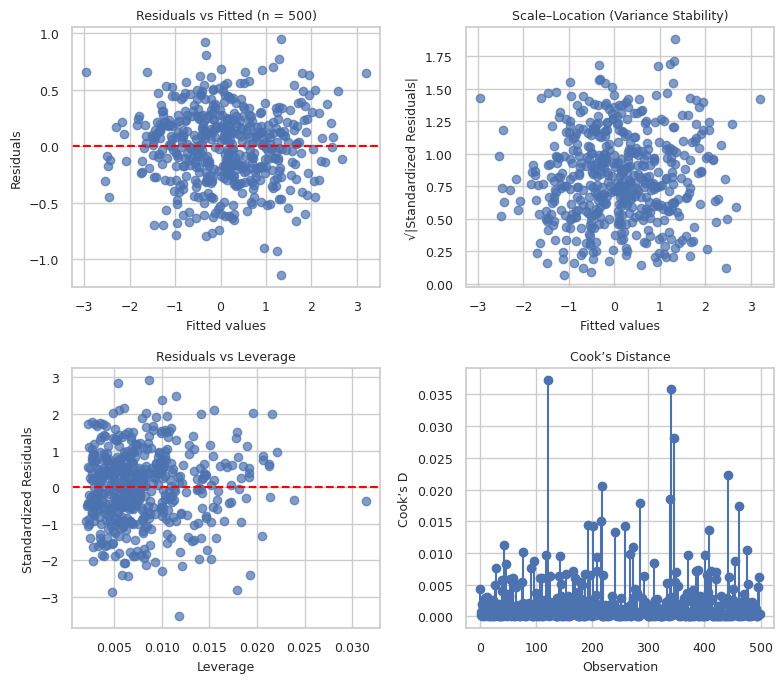

In [ ]:
# -------------------------------------------
# Model Fit Diagnostics on a Smaller Sample (n_sample = 500)
# -------------------------------------------

import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Set sample size
n_sample = 500

# Randomly sample without replacement
df_small = df_reg.sample(n=n_sample, random_state=42)

# Prepare data
X_small = sm.add_constant(df_small[["feature_strong", "feature_weak", "feature_noise"]])
y_small = df_small["target_reg"]

# Fit regression model
model_small = sm.OLS(y_small, X_small).fit()

# Extract diagnostics
fitted_small = model_small.fittedvalues
residuals_small = model_small.resid
influence_small = model_small.get_influence()
standardized_resid_small = influence_small.resid_studentized_internal
leverage_small = influence_small.hat_matrix_diag
cooks_small = influence_small.cooks_distance[0]

# -------------------------------------------
# Diagnostic Plots (2x2)
# -------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(8, 7))

# 1. Residuals vs Fitted
axes[0, 0].scatter(fitted_small, residuals_small, alpha=0.7)
axes[0, 0].axhline(0, color="red", linestyle="--")
axes[0, 0].set_title(f"Residuals vs Fitted (n = {n_sample})", fontsize=9)
axes[0, 0].set_xlabel("Fitted values", fontsize=9)
axes[0, 0].set_ylabel("Residuals", fontsize=9)
axes[0, 0].tick_params(labelsize=9)

# 2. Scale–Location
axes[0, 1].scatter(fitted_small, np.sqrt(np.abs(standardized_resid_small)), alpha=0.7)
axes[0, 1].set_title("Scale–Location (Variance Stability)", fontsize=9)
axes[0, 1].set_xlabel("Fitted values", fontsize=9)
axes[0, 1].set_ylabel("√|Standardized Residuals|", fontsize=9)
axes[0, 1].tick_params(labelsize=9)

# 3. Residuals vs Leverage
axes[1, 0].scatter(leverage_small, standardized_resid_small, alpha=0.7)
axes[1, 0].axhline(0, color="red", linestyle="--")
axes[1, 0].set_title("Residuals vs Leverage", fontsize=9)
axes[1, 0].set_xlabel("Leverage", fontsize=9)
axes[1, 0].set_ylabel("Standardized Residuals", fontsize=9)
axes[1, 0].tick_params(labelsize=9)

# 4. Cook’s Distance
axes[1, 1].stem(np.arange(len(cooks_small)), cooks_small, basefmt=" ")
axes[1, 1].set_title("Cook’s Distance", fontsize=9)
axes[1, 1].set_xlabel("Observation", fontsize=9)
axes[1, 1].set_ylabel("Cook’s D", fontsize=9)
axes[1, 1].tick_params(labelsize=9)

plt.tight_layout()
plt.show()
export_plot(fig, "sim_model_fit_diagnostics", height=7)

## Statistical Error & Variability

### Model Fit & Prediction Error Metrics

In [ ]:
# -------------------------------------------
# Model Fit & Prediction Error Metrics (statsmodels version)
# -------------------------------------------

from sklearn.metrics import mean_squared_error, mean_absolute_error

# Use the SAME statsmodels regression already fit
X = sm.add_constant(df_reg[["feature_strong", "feature_weak", "feature_noise"]])
y_true = df_reg["target_reg"]

model = sm.OLS(y_true, X).fit()
y_pred = model.fittedvalues

# Core metrics
SSE  = np.sum((y_true - y_pred)**2)
MSE  = mean_squared_error(y_true, y_pred)
RMSE = np.sqrt(MSE)
MAE  = mean_absolute_error(y_true, y_pred)
MAPE = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

metrics = pd.DataFrame({
    "Value": [SSE, MSE, RMSE, MAE, MAPE]
}, index=["SSE", "MSE", "RMSE", "MAE", "MAPE"])

print(metrics.to_string())

           Value
SSE   140.937079
MSE     0.093958
RMSE    0.306526
MAE     0.244358
MAPE  121.950093


### Statistical Error & Variability: Error Metrics, Fit Metrics, Uncertainty

Model Error Metrics:
  Metric       Value
0    SSE  140.937079
1    MSE    0.093958
2   RMSE    0.306526
3    MAE    0.244358
4   MAPE  121.950093


R²: 0.9041135179144565
Adjusted R²: 0.9039212321883491


Residual Variance (σ²): 0.09420927746114698

Coefficient Standard Errors:
const             0.007947
feature_strong    0.005166
feature_weak      0.007776
feature_noise     0.007914
dtype: float64


Coefficient Confidence Intervals:
                       0         1
const          -0.013658  0.017517
feature_strong  0.581044  0.601311
feature_weak    0.012794  0.043298
feature_noise  -0.016175  0.014872


Prediction Summary (first 5 rows):
       mean  mean_ci_lower  mean_ci_upper  obs_ci_lower  obs_ci_upper
0  0.623772       0.586393       0.661150      0.020543      1.227000
1 -0.308015      -0.336766      -0.279264     -0.910771      0.294740
2  0.329309       0.299878       0.358740     -0.273479      0.932097
3  1.416991       1.375701       1.458282      0.813508      2.020475

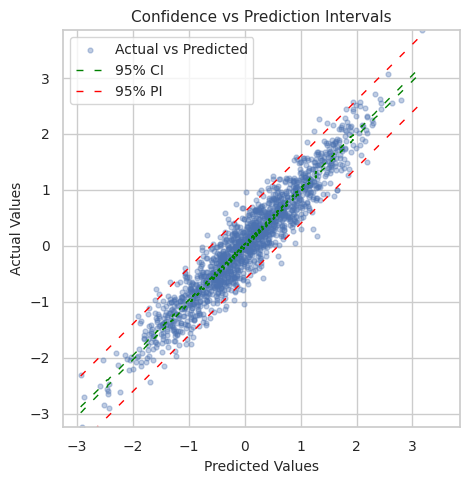

In [ ]:
# -------------------------------------------
# Statistical Error & Variability: Error Metrics, Fit Metrics, Uncertainty
# -------------------------------------------

import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Prepare data (same as before)
X = sm.add_constant(df_reg[["feature_strong", "feature_weak", "feature_noise"]])
y = df_reg["target_reg"]
model = sm.OLS(y, X).fit()

# Predictions
y_pred = model.fittedvalues

# -------------------------------------------
# Error Metrics
# -------------------------------------------

SSE  = np.sum((y - y_pred)**2)
MSE  = mean_squared_error(y, y_pred)
RMSE = np.sqrt(MSE)
MAE  = mean_absolute_error(y, y_pred)
MAPE = np.mean(np.abs((y - y_pred) / y)) * 100

metrics = pd.DataFrame({
    "Metric": ["SSE", "MSE", "RMSE", "MAE", "MAPE"],
    "Value":  [SSE, MSE, RMSE, MAE, MAPE]
})

print("Model Error Metrics:")
print(metrics)
print("\n")

# -------------------------------------------
# Fit Metrics: R² and Adjusted R²
# -------------------------------------------

print("R²:", model.rsquared)
print("Adjusted R²:", model.rsquared_adj)
print("\n")

# -------------------------------------------
# Residual Variance (σ²) and Standard Errors
# -------------------------------------------

sigma2 = model.mse_resid   # residual variance estimate
coef_se = model.bse        # standard errors of coefficients

print("Residual Variance (σ²):", sigma2)
print("\nCoefficient Standard Errors:")
print(coef_se)
print("\n")

# -------------------------------------------
# Confidence vs Prediction Intervals
# -------------------------------------------

# Confidence intervals for coefficients
coef_ci = model.conf_int()
print("Coefficient Confidence Intervals:")
print(coef_ci)
print("\n")

# Confidence & prediction intervals for fitted values
pred = model.get_prediction(X)
pred_summary = pred.summary_frame(alpha=0.05)[["mean", "mean_ci_lower", "mean_ci_upper",
                                               "obs_ci_lower", "obs_ci_upper"]]

print("Prediction Summary (first 5 rows):")
print(pred_summary.head())

# -------------------------------------------
# Plot: Confidence vs Prediction Intervals
# -------------------------------------------

fig, ax = plt.subplots(figsize=(8, 5))

# Scatter (unsorted)
ax.scatter(y_pred, y, alpha=0.35, s=12, label="Actual vs Predicted")

# Sort by predicted values for smooth interval lines
sort_idx = np.argsort(y_pred)
x_sorted = y_pred.iloc[sort_idx]
ci_lower_sorted = pred_summary["mean_ci_lower"].iloc[sort_idx]
ci_upper_sorted = pred_summary["mean_ci_upper"].iloc[sort_idx]
pi_lower_sorted = pred_summary["obs_ci_lower"].iloc[sort_idx]
pi_upper_sorted = pred_summary["obs_ci_upper"].iloc[sort_idx]

dash_style = (5, 8)

# CI lines
ax.plot(x_sorted, ci_lower_sorted, color="green", linewidth=1, dashes=dash_style, label="95% CI")
ax.plot(x_sorted, ci_upper_sorted, color="green", linewidth=1, dashes=dash_style)

# PI lines
ax.plot(x_sorted, pi_lower_sorted, color="red", linewidth=1, dashes=dash_style, label="95% PI")
ax.plot(x_sorted, pi_upper_sorted, color="red", linewidth=1, dashes=dash_style)

# ---- Equal numeric range AND equal aspect ----
min_val = min(y_pred.min(), y.min())
max_val = max(y_pred.max(), y.max())
ax.set_xlim(min_val, max_val)
ax.set_ylim(min_val, max_val)

ax.set_aspect("equal", adjustable="box")  # <- this is the missing piece

# Labels & title
ax.set_xlabel("Predicted Values", fontsize=10)
ax.set_ylabel("Actual Values", fontsize=10)
ax.set_title("Confidence vs Prediction Intervals", fontsize=11)
ax.legend(fontsize=10)
ax.tick_params(labelsize=10)

fig.tight_layout()
plt.show()
export_plot(fig, "sim_confidence_vs_prediction_intervals")

## ML‑Context Diagnostics

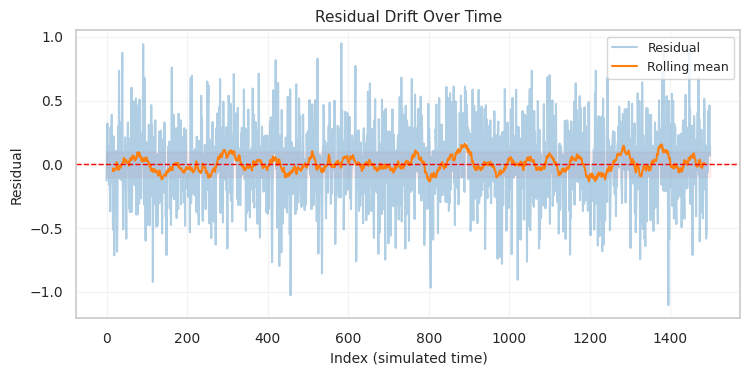

/tmp/ipykernel_28787/3298527363.py:77: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  segment_perf = df.groupby("segment", observed=False).apply(seg_metrics)
/tmp/ipykernel_28787/3298527363.py:95: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fairness_perf = df.groupby("group", observed=False).apply(fairness_metrics)


Segment-Level Performance:
          RMSE    MAE
segment              
Q1      0.3064 0.2423
Q2      0.3159 0.2535
Q3      0.2933 0.2345
Q4      0.3100 0.2471


Fairness Slice Performance:
        RMSE    MAE  Mean Residual
group                             
A     0.3031 0.2409        -0.0005
B     0.3123 0.2503         0.0009


Robustness Check:
RMSE with noisy inputs: 0.3101


In [ ]:
# ============================================================
# Demonstrates four ML diagnostics: Drift, Segments, Fairness, Robustness
#
# What this chart demonstrates
# - Drift:    how residuals evolve over (simulated) time and whether model bias changes.
# - Segments: per-segment performance (quartiles of a strong feature) to reveal range-specific errors.
# - Fairness: performance and mean residuals by protected group to surface systematic bias.
# - Robustness: sensitivity of predictions to small input perturbations.
#
# Why the simulated data intentionally shows near-zero bias (no drift)
# - The data generation is controlled so the regression target (target_reg) is created first,
#   and features are constructed as noisy linear functions of that same target. An OLS model
#   fit on those features therefore closely recovers the original signal. Because the model
#   is trained and evaluated on the same simulated relationship and no time-dependent
#   perturbations are introduced, fitted values closely match target_reg and residuals are
#   near zero and stationary. This is intentional: the simulation provides a clean baseline
#   (no drift, minimal bias) so diagnostics can be validated; to exercise drift detection,
#   inject a trend, variance change, or abrupt shift into the data generation.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
import statsmodels.api as sm

# Use existing predictions
df = df_reg.copy()
# Recreate predictions robustly (use same design matrix used for fitting)
X = sm.add_constant(df[["feature_strong", "feature_weak", "feature_noise"]])
df["pred"] = model.predict(X)
df["residual"] = df["target_reg"] - df["pred"]

# -------------------------------------------
# 1. Residual Drift Over Time (simulate time by index)
#    — formatted and exported; fonts: axes=10, legend=9, title=11
# -------------------------------------------

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(df.index, df["residual"], color="tab:blue", alpha=0.35, label="Residual")
# rolling mean to show slow drift (window scaled to data length)
roll_win = max(5, int(len(df) * 0.02))
roll = df["residual"].rolling(window=roll_win, center=True).mean()
ax.plot(df.index, roll, color="tab:orange", linewidth=1.5, label="Rolling mean")
ax.axhline(0, color="red", linestyle="--", linewidth=1)
# small zero band for visual tolerance
ax.fill_between(df.index, -0.1, 0.1, color="red", alpha=0.06)

# Fonts and labels
ax.set_title("Residual Drift Over Time", fontsize=11)
ax.set_xlabel("Index (simulated time)", fontsize=10)
ax.set_ylabel("Residual", fontsize=10)
ax.tick_params(labelsize=10)
leg = ax.legend(loc="upper right", fontsize=9)
ax.grid(alpha=0.2)
fig.tight_layout()

# Export the residual drift figure
export_plot(fig, "sim_residual_drift_over_time", height=4)

plt.show()

# -------------------------------------------
# 2. Segment-Level Performance (quartiles of strong feature)
# -------------------------------------------

df["segment"] = pd.qcut(df["feature_strong"], q=4, labels=["Q1","Q2","Q3","Q4"])

def seg_metrics(g):
    if len(g) < 2:
        return pd.Series({"RMSE": np.nan, "MAE": np.nan})
    return pd.Series({
        "RMSE": np.sqrt(mean_squared_error(g["target_reg"], g["pred"])),
        "MAE": mean_absolute_error(g["target_reg"], g["pred"])
    })

segment_perf = df.groupby("segment", observed=False).apply(seg_metrics)
print("Segment-Level Performance:")
print(segment_perf.to_string(float_format="%.4f"))
print("\n")

# -------------------------------------------
# 3. Fairness Slices (using existing 'group' column)
# -------------------------------------------

def fairness_metrics(g):
    if len(g) < 2:
        return pd.Series({"RMSE": np.nan, "MAE": np.nan, "Mean Residual": np.nan})
    return pd.Series({
        "RMSE": np.sqrt(mean_squared_error(g["target_reg"], g["pred"])),
        "MAE": mean_absolute_error(g["target_reg"], g["pred"]),
        "Mean Residual": g["residual"].mean()
    })

fairness_perf = df.groupby("group", observed=False).apply(fairness_metrics)
print("Fairness Slice Performance:")
print(fairness_perf.to_string(float_format="%.4f"))
print("\n")

# -------------------------------------------
# 4. Robustness Check (add noise to strong feature)
# -------------------------------------------

df_robust = df.copy()
rng = np.random.default_rng(12345)
df_robust["feature_strong_noisy"] = df_robust["feature_strong"] + rng.normal(0, 0.1, len(df_robust))

X_robust = sm.add_constant(df_robust[["feature_strong_noisy", "feature_weak", "feature_noise"]])
pred_robust = model.predict(X_robust)

robust_rmse = np.sqrt(mean_squared_error(df["target_reg"], pred_robust))

print("Robustness Check:")
print(f"RMSE with noisy inputs: {robust_rmse:.4f}")

export_plot(fig, "sim_residual_drift_over_time")